<a href="https://colab.research.google.com/github/elsakhalil1968-lgtm/Rudolph-Rodriguez-Quamina/blob/main/kaggle_Data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from google.colab import drive
drive.mount('/content/drive')
#

Mounted at /content/drive


In [3]:

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_healthcare_dataset.csv')

In [4]:
df.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [5]:
df.tail()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
4995,42,Female,15.3,2,1,1,92,292,121,0,1,1,0,0,0,100.0
4996,39,Female,24.2,0,1,1,140,156,83,0,0,0,0,0,0,100.0
4997,48,Female,19.2,2,0,0,135,247,89,1,1,1,0,0,0,100.0
4998,34,Male,24.0,0,1,1,144,254,187,1,1,1,0,0,0,100.0
4999,72,Female,29.9,1,0,1,115,179,121,1,0,0,1,1,1,100.0


In [6]:
df.info

<bound method DataFrame.info of       age  gender   bmi  exercise_level  smoking  alcohol  blood_pressure  \
0      56    Male  22.6               2        1        1             169   
1      69  Female  28.2               0        1        1             136   
2      46  Female  25.1               1        0        1             142   
3      32  Female  18.0               0        0        1             173   
4      60  Female  20.1               2        1        0             130   
...   ...     ...   ...             ...      ...      ...             ...   
4995   42  Female  15.3               2        1        1              92   
4996   39  Female  24.2               0        1        1             140   
4997   48  Female  19.2               2        0        0             135   
4998   34    Male  24.0               0        1        1             144   
4999   72  Female  29.9               1        0        1             115   

      cholesterol  glucose  fatigue  chest_pain  dizziness  heart_disease  \
0             225       74        0           1          0              0   
1             230      198        0           1          0              1   
2             221       89        0           1          1              0   
3             296      152        1           0          0              0   
4             292      133        1           1          1              0   
...           ...      ...      ...         ...        ...            ...   
4995          292      121        0           1          1              0   
4996          156       83        0           0          0              0   
4997          247       89        1           1          1              0   
4998          254      187        1           1          1              0   
4999          179      121        1           0          0              1   

      diabetes  stroke  health_risk_score  
0            0       0              100.0  
1            1       1              100.0  
2            0       0              100.0  
3            0       0              100.0  
4            1       0              100.0  
...        ...     ...                ...  
4995         0       0              100.0  
4996         0       0              100.0  
4997         0       0              100.0  
4998         0       0              100.0  
4999         1       1              100.0  

[5000 rows x 16 columns]>

In [7]:
df.shape


(5000, 16)

In [8]:
df.describe()

,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,48.805600,24.967800,1.005800,0.507600,0.501400,134.445400,224.616400,134.497400,0.515200,0.504000,0.497400,0.299800,0.349200,0.248600,100.0
std,17.906991,4.960379,0.815291,0.499992,0.500048,26.191438,43.129773,37.437028,0.499819,0.500034,0.500043,0.458216,0.476765,0.432245,0.0
min,18.000000,15.000000,0.000000,0.000000,0.000000,90.000000,150.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,34.000000,21.500000,0.000000,0.000000,0.000000,111.000000,187.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
50%,49.000000,24.900000,1.000000,1.000000,1.000000,134.000000,226.000000,134.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.0
75%,64.000000,28.400000,2.000000,1.000000,1.000000,157.000000,262.000000,167.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,100.0
max,79.000000,42.600000,2.000000,1.000000,1.000000,179.000000,299.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.0


In [9]:
df.columns

Index(['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol',
       'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain',
       'dizziness', 'heart_disease', 'diabetes', 'stroke',
       'health_risk_score'],
      dtype='object')

In [10]:
df.dtypes

,0
age,int64
gender,object
bmi,float64
exercise_level,int64
smoking,int64
alcohol,int64
blood_pressure,int64
cholesterol,int64
glucose,int64
fatigue,int64


In [11]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
exercise_level,0
smoking,0
alcohol,0
blood_pressure,0
cholesterol,0
glucose,0
fatigue,0


In [12]:
df.describe()

,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,48.805600,24.967800,1.005800,0.507600,0.501400,134.445400,224.616400,134.497400,0.515200,0.504000,0.497400,0.299800,0.349200,0.248600,100.0
std,17.906991,4.960379,0.815291,0.499992,0.500048,26.191438,43.129773,37.437028,0.499819,0.500034,0.500043,0.458216,0.476765,0.432245,0.0
min,18.000000,15.000000,0.000000,0.000000,0.000000,90.000000,150.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,34.000000,21.500000,0.000000,0.000000,0.000000,111.000000,187.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
50%,49.000000,24.900000,1.000000,1.000000,1.000000,134.000000,226.000000,134.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.0
75%,64.000000,28.400000,2.000000,1.000000,1.000000,157.000000,262.000000,167.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,100.0
max,79.000000,42.600000,2.000000,1.000000,1.000000,179.000000,299.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.0


In [13]:
df.duplicated().sum()


np.int64(0)

In [14]:
def show_fig():
  plt.tight_layout()
  plt.show()

plot_no = 1

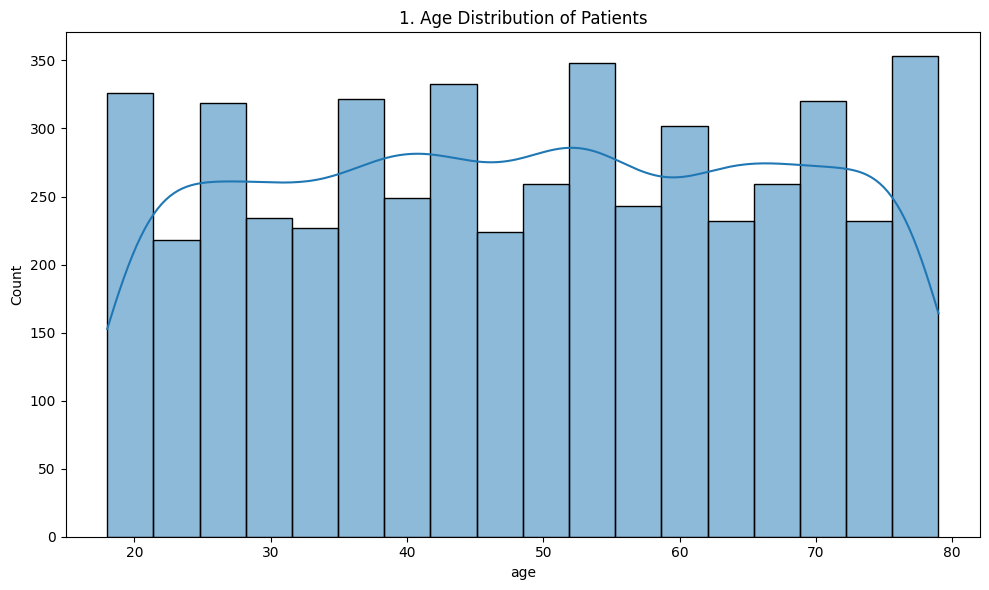

In [15]:


fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Patients')
show_fig()
plot_no += 1



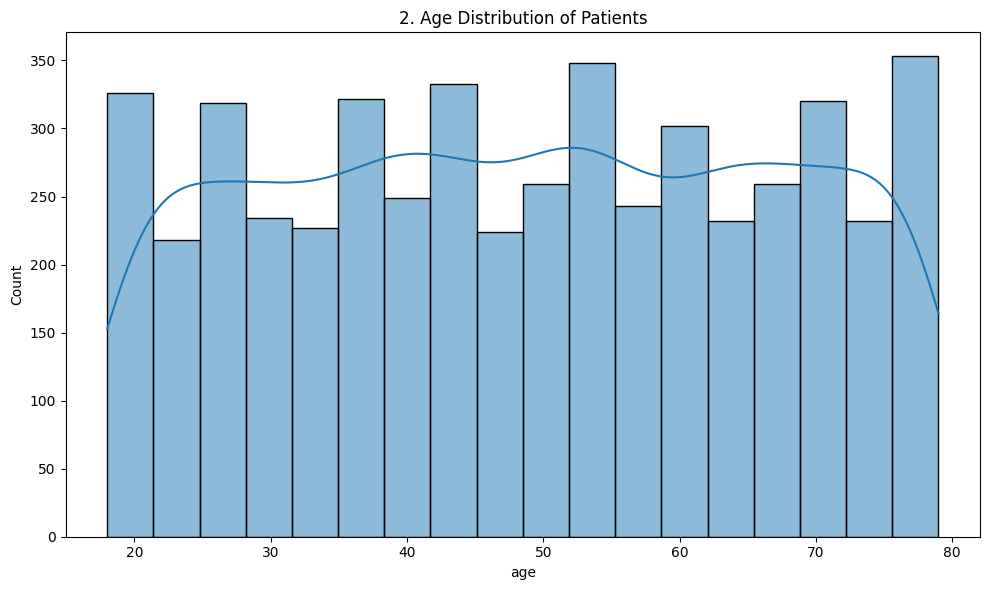

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde = True)
plt.title(f'{plot_no}. Age Distribution of Patients')
show_fig()
plot_no += 1

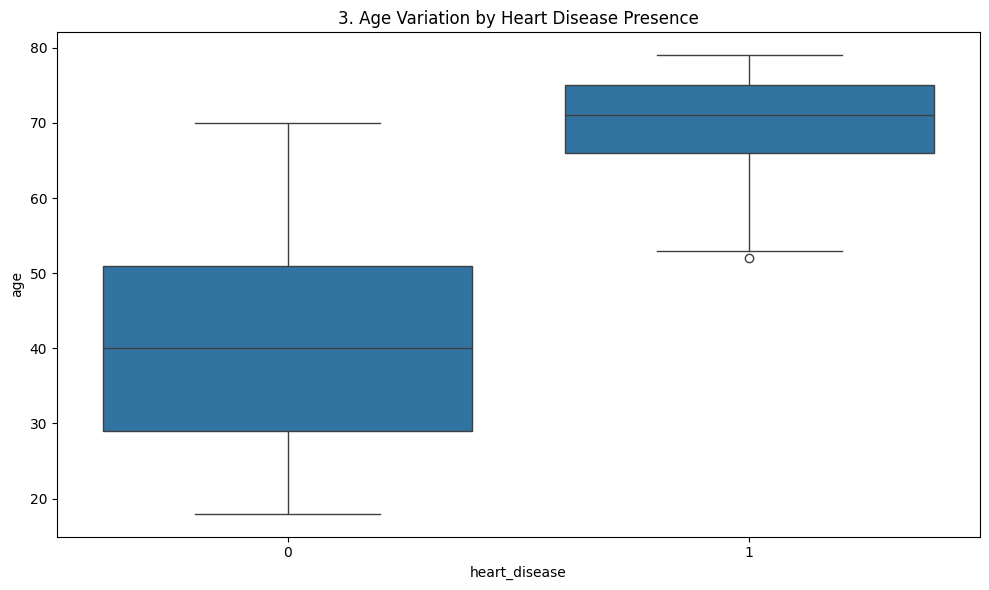

In [17]:


fig = plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title(f'{plot_no}. Age Variation by Heart Disease Presence')
show_fig()
plot_no += 1



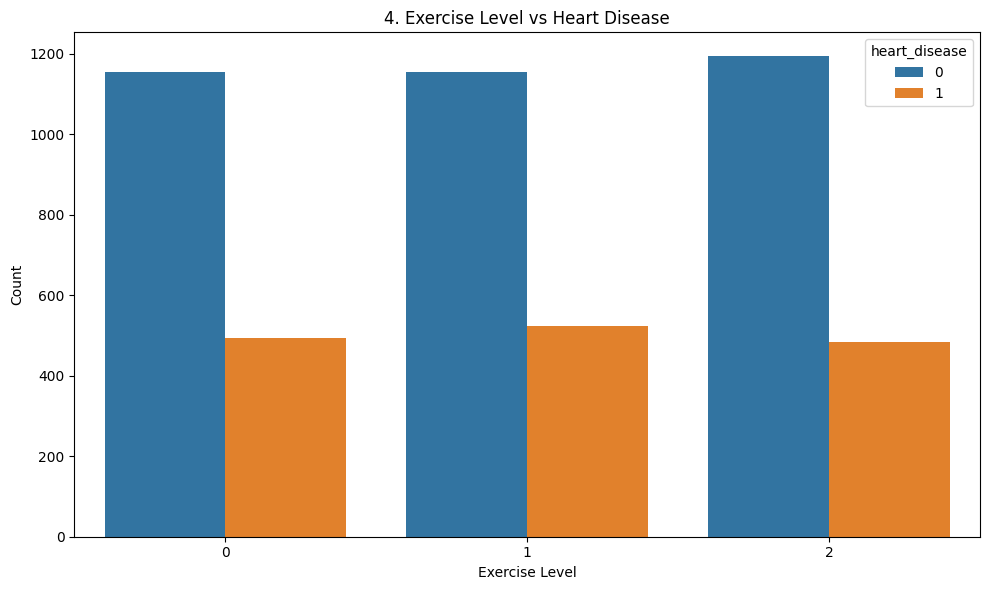

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='exercise_level', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Exercise Level vs Heart Disease')
plt.xlabel('Exercise Level')
plt.ylabel('Count')
show_fig()

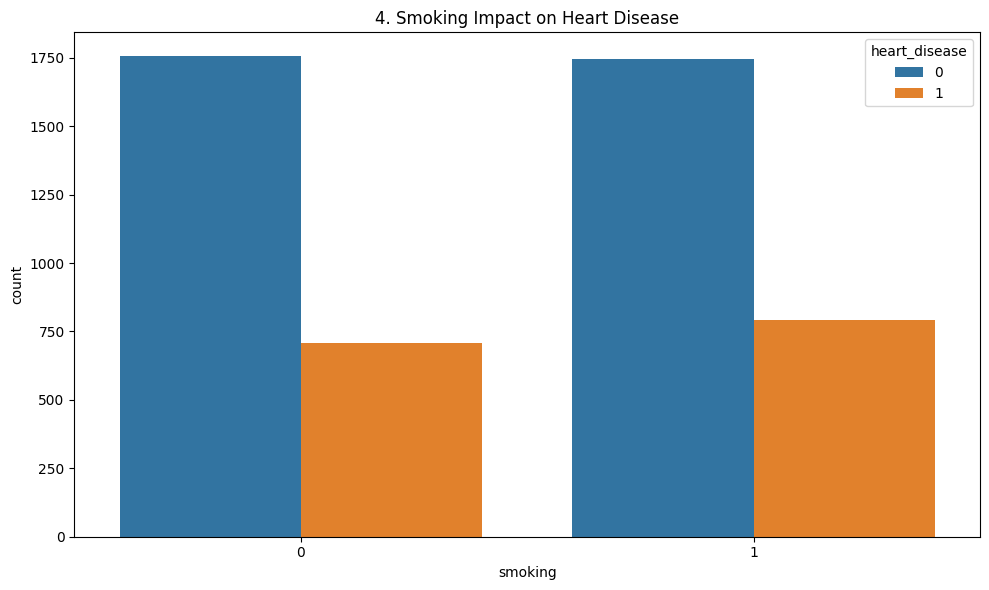

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='smoking', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Smoking Impact on Heart Disease')
show_fig()
plot_no += 1

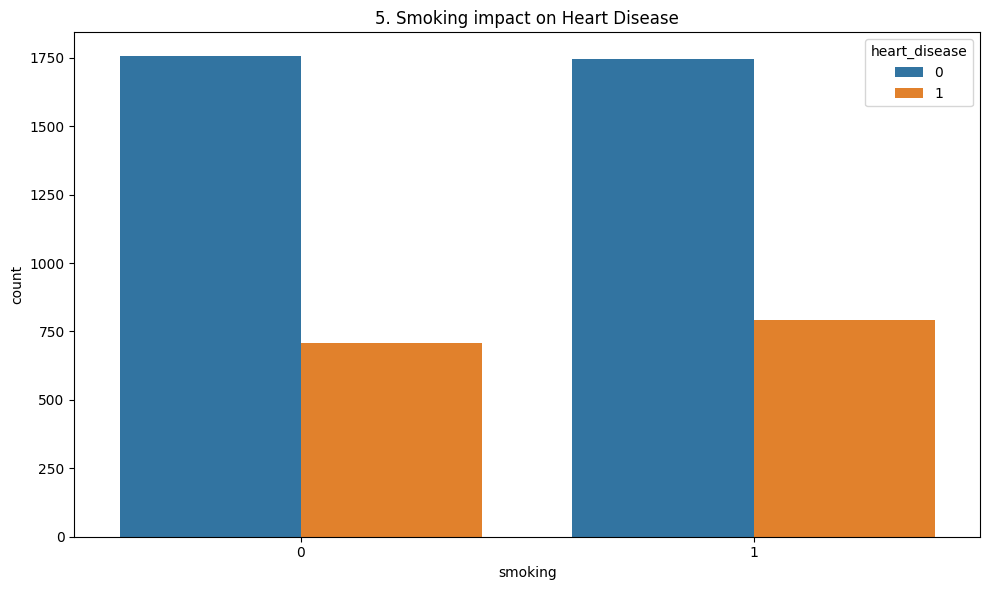

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='smoking', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Smoking impact on Heart Disease')
show_fig()

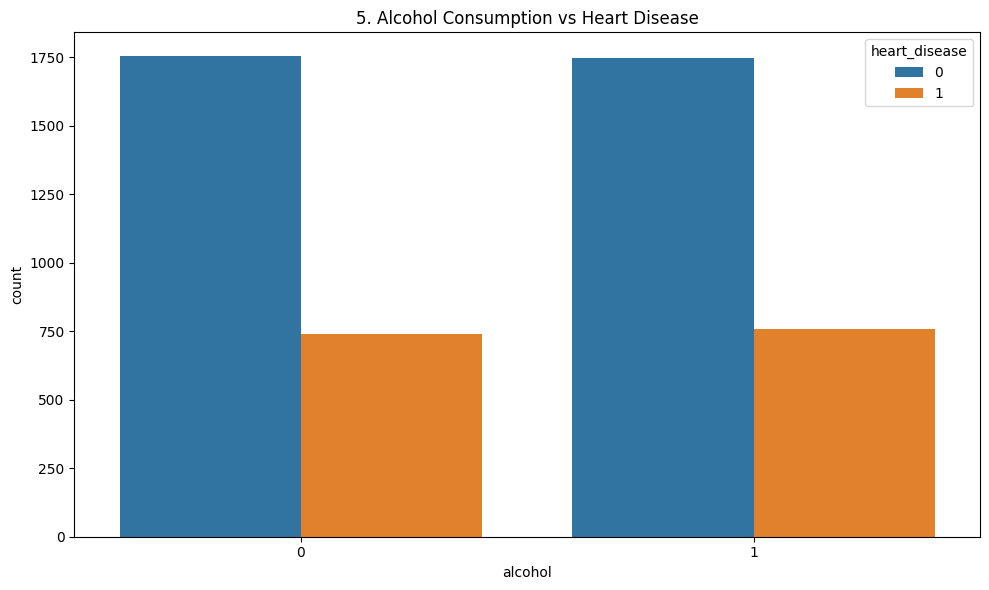

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='alcohol', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Alcohol Consumption vs Heart Disease')
show_fig()
plot_no += 1



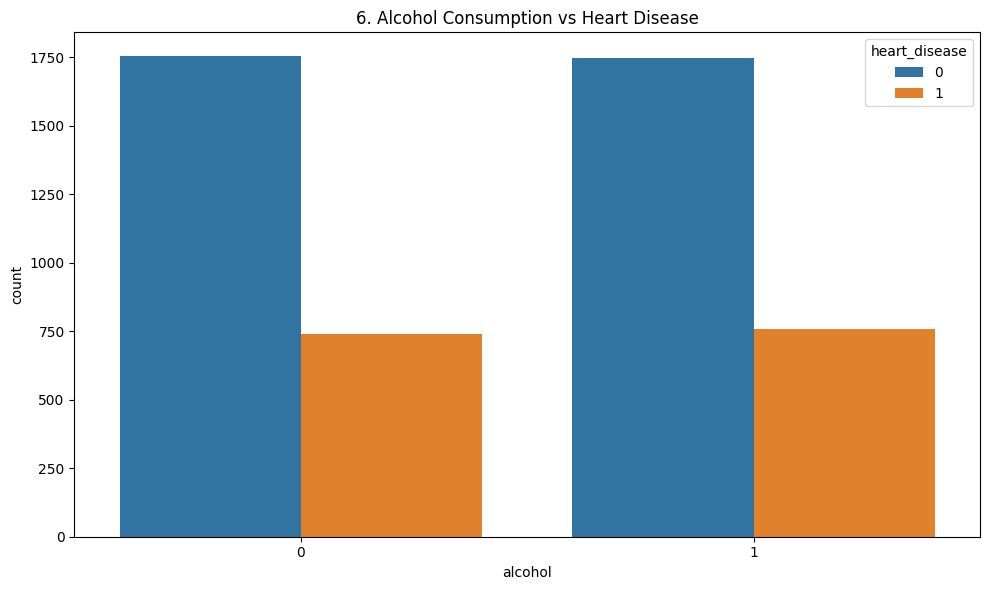

In [22]:
fig = plt.figure(figsize = (10,6))
sns.countplot(x='alcohol', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Alcohol Consumption vs Heart Disease')
show_fig()
plot_no += 1

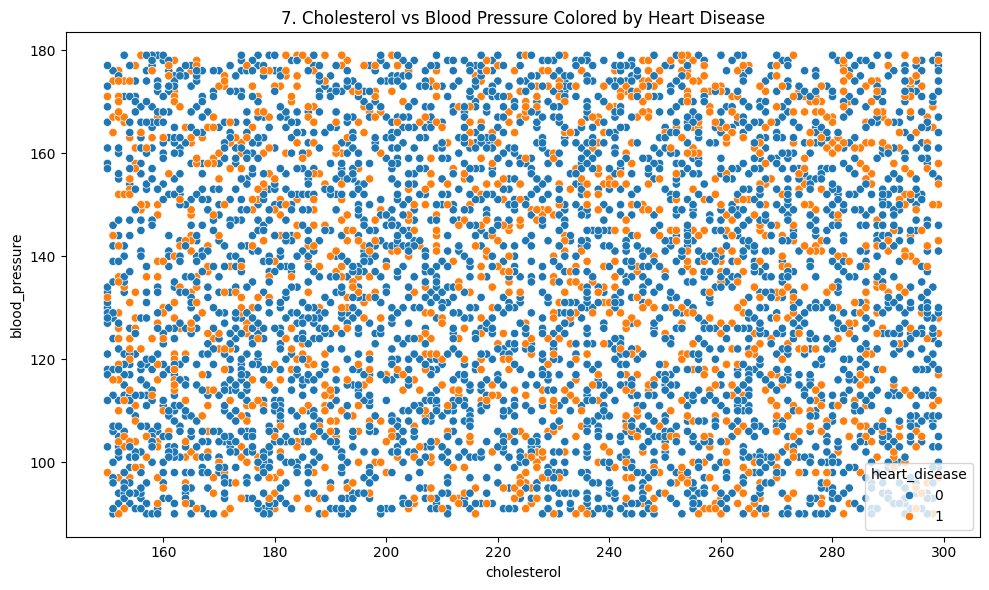

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='cholesterol', y = 'blood_pressure' , hue='heart_disease', data=df)
plt.title(f'{plot_no}. Cholesterol vs Blood Pressure Colored by Heart Disease')
show_fig()
plot_no += 1


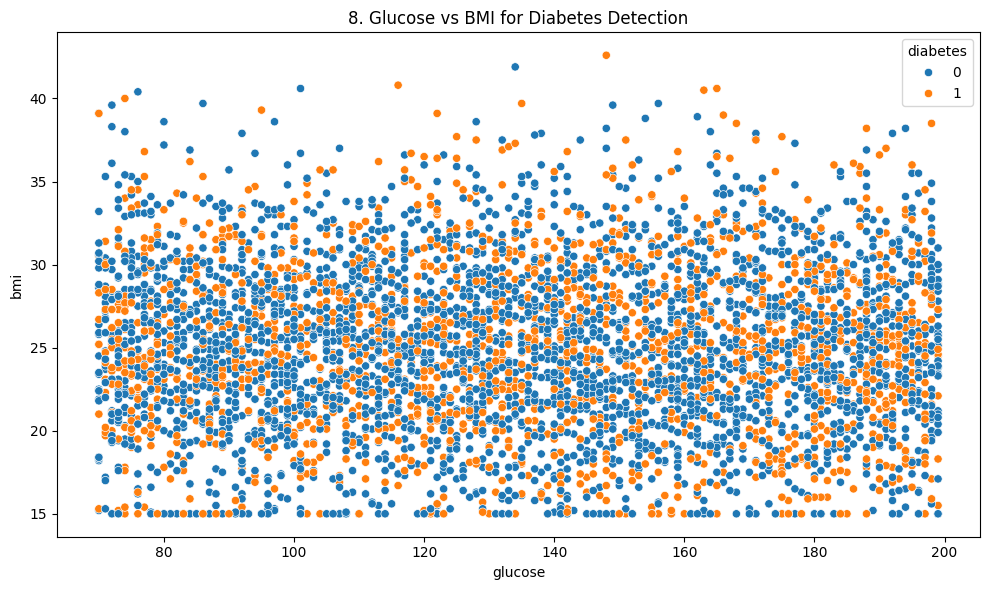

In [24]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x='glucose', y = 'bmi', hue='diabetes', data=df)
plt.title(f'{plot_no}. Glucose vs BMI for Diabetes Detection')
show_fig()
plot_no += 1

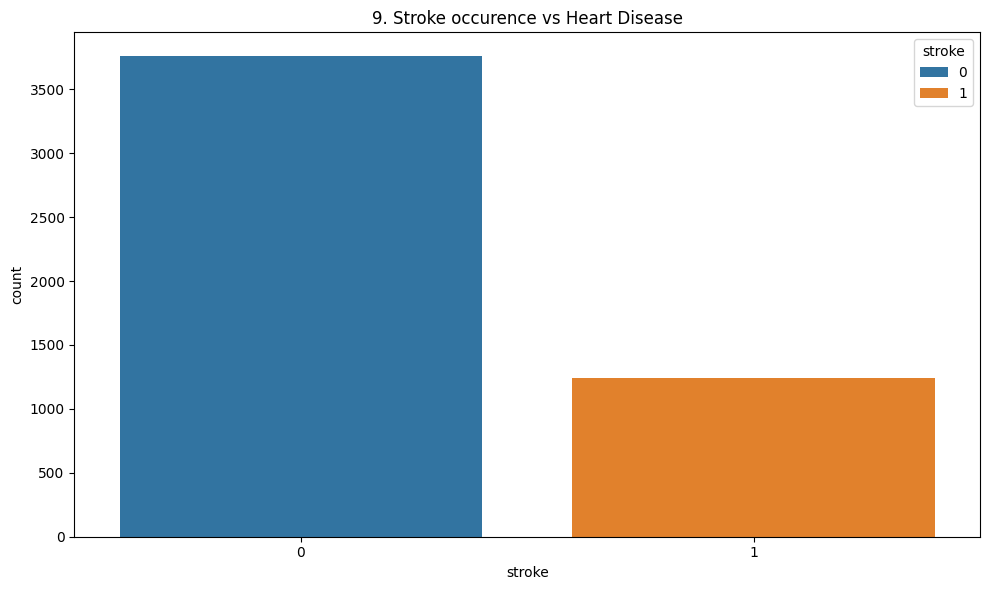

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='stroke', hue='stroke', data=df)
plt.title(f'{plot_no}. Stroke occurence vs Heart Disease')
show_fig()
plot_no += 1

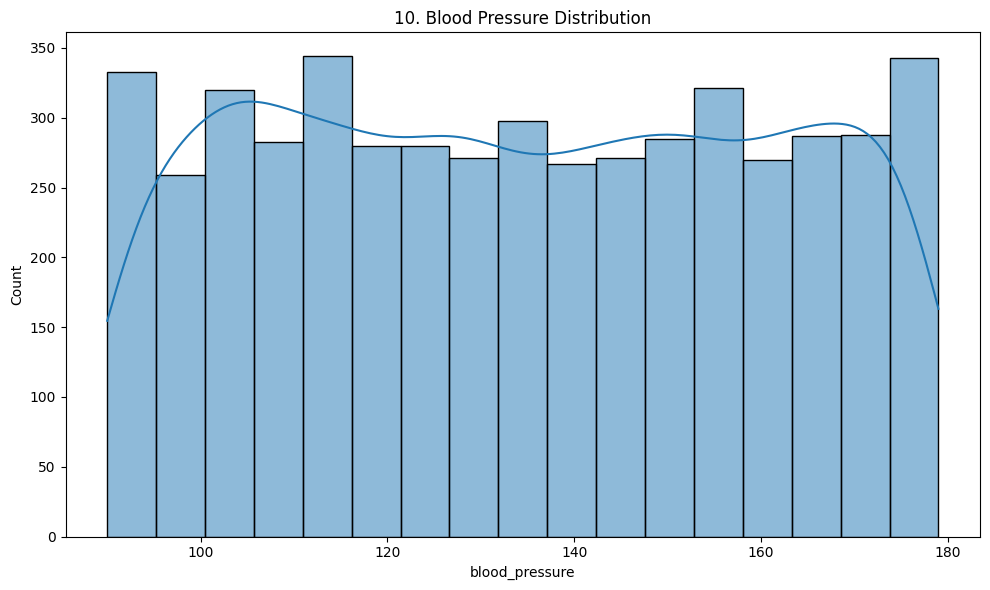

In [26]:
ig = plt.figure(figsize=(10,6))
sns.histplot(df['blood_pressure'], kde=True)
plt.title(f'{plot_no}. Blood Pressure Distribution')
show_fig()
plot_no += 1

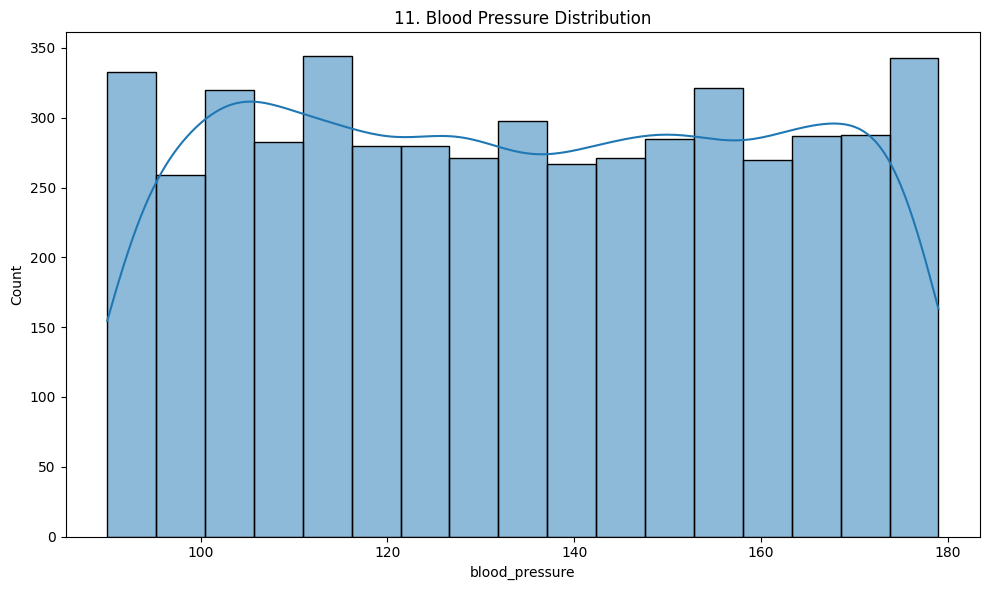

In [27]:
fig = plt.figure(figsize= (10,6))
sns.histplot(df['blood_pressure'], kde = True)
plt.title(f'{plot_no}. Blood Pressure Distribution')
show_fig()
plot_no += 1

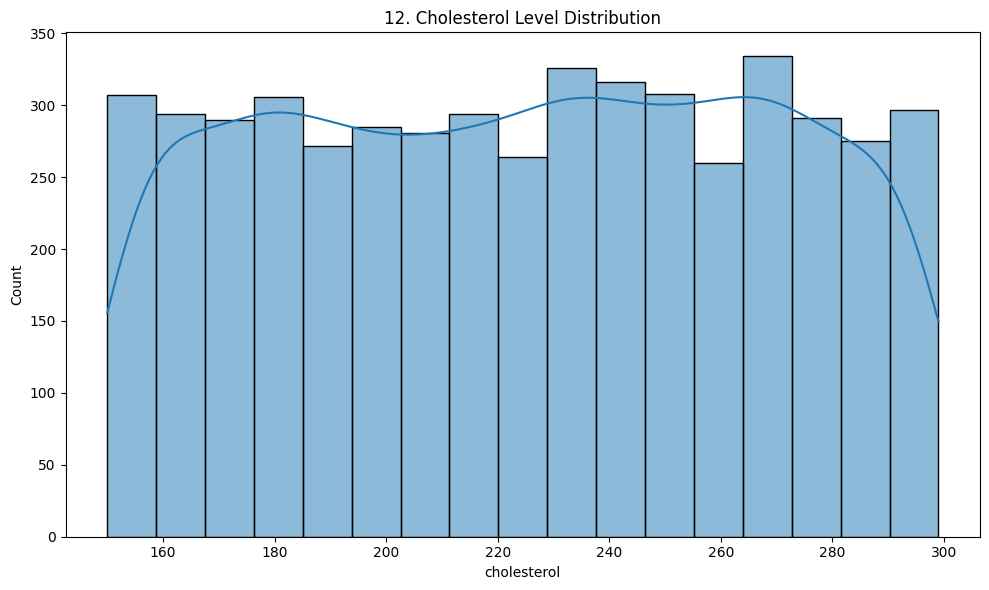

In [28]:


fig = plt.figure(figsize=(10,6))
sns.histplot(df['cholesterol'], kde=True)
plt.title(f'{plot_no}. Cholesterol Level Distribution')
show_fig()
plot_no += 1



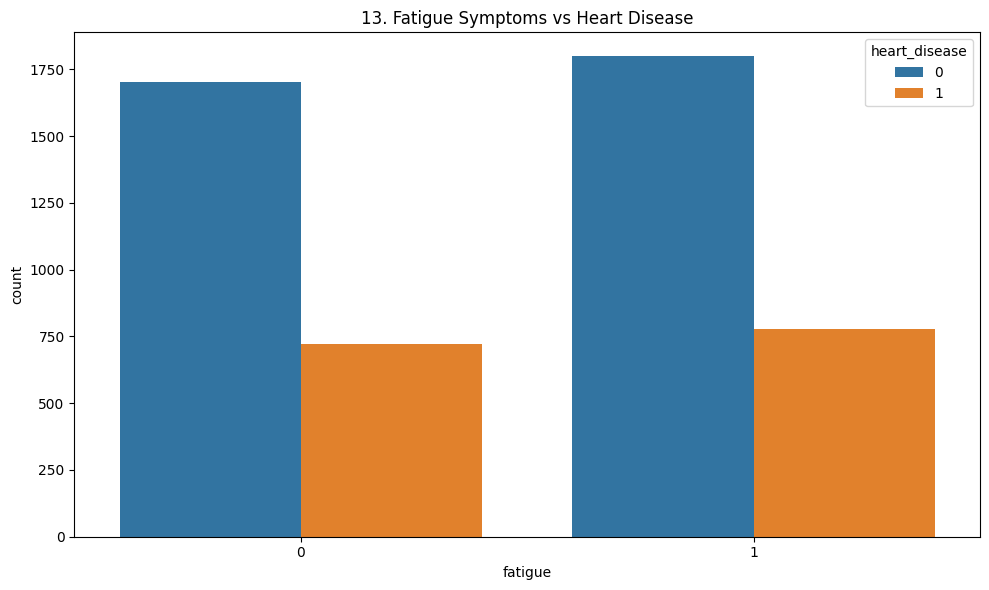

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='fatigue', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Fatigue Symptoms vs Heart Disease')
show_fig()
plot_no += 1

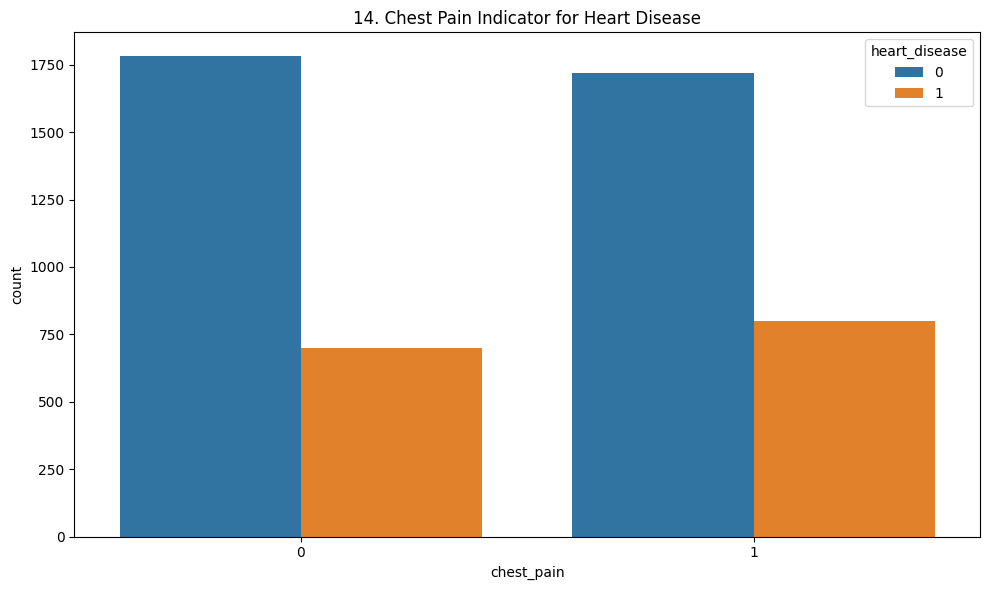

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='chest_pain', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Chest Pain Indicator for Heart Disease')
show_fig()
plot_no += 1

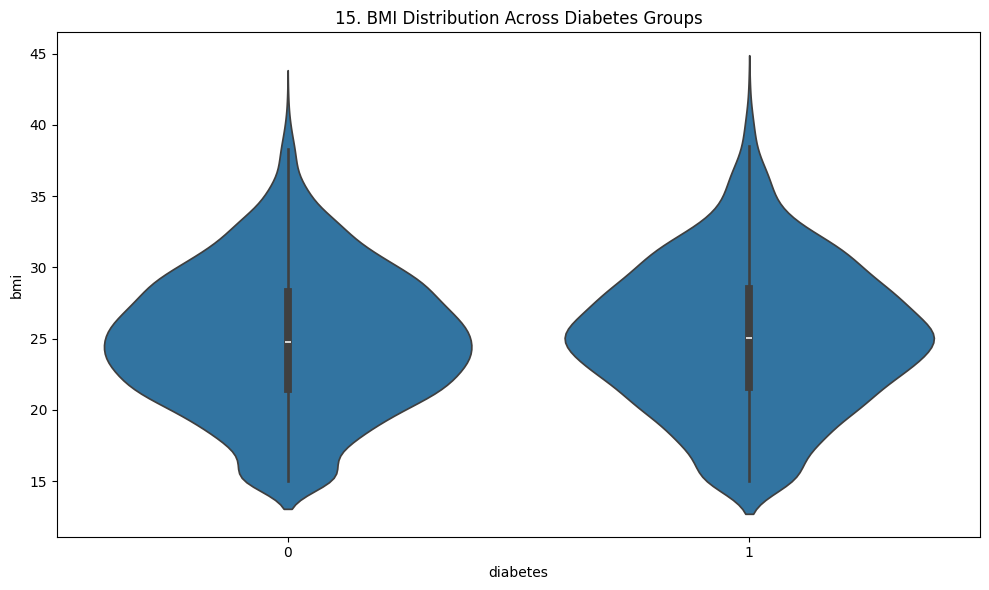

In [31]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='diabetes', y='bmi', data=df)
plt.title(f'{plot_no}. BMI Distribution Across Diabetes Groups')
show_fig()
plot_no += 1



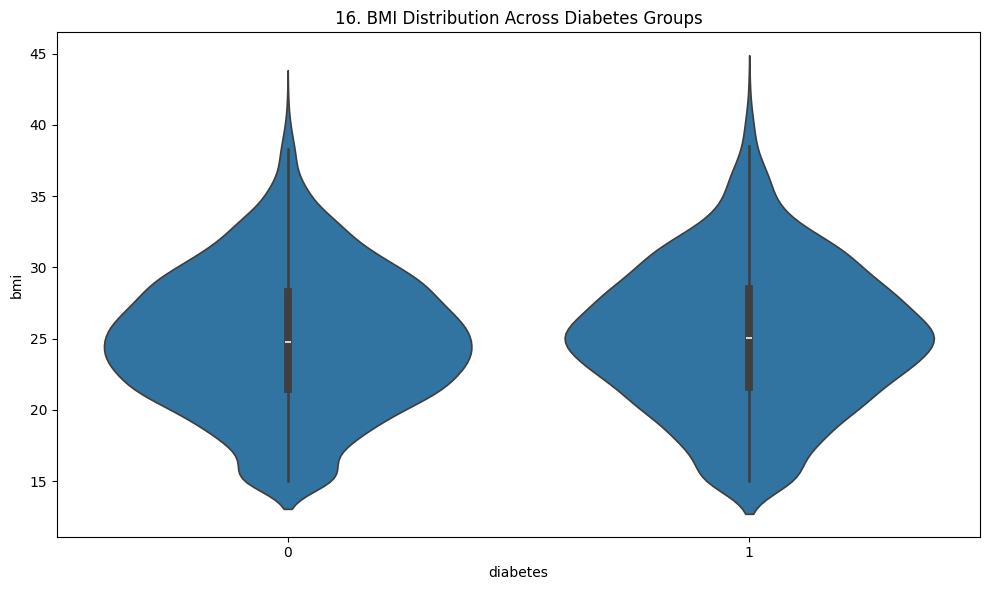

In [32]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='diabetes',y ='bmi', data=df)
plt.title(f'{plot_no}. BMI Distribution Across Diabetes Groups')
show_fig()
plot_no += 1

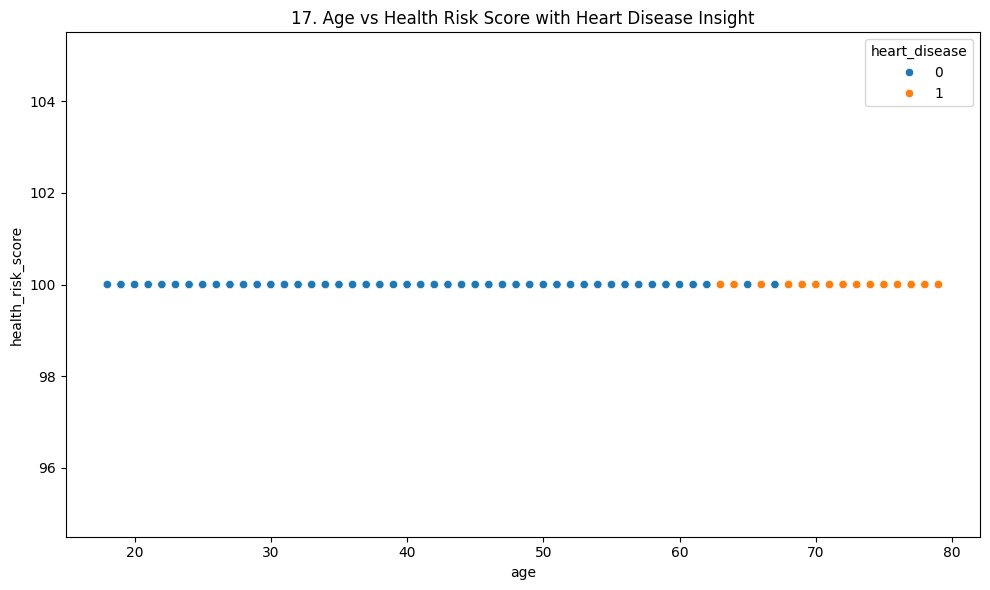

In [33]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='health_risk_score', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Age vs Health Risk Score with Heart Disease Insight')
show_fig()
plot_no += 1

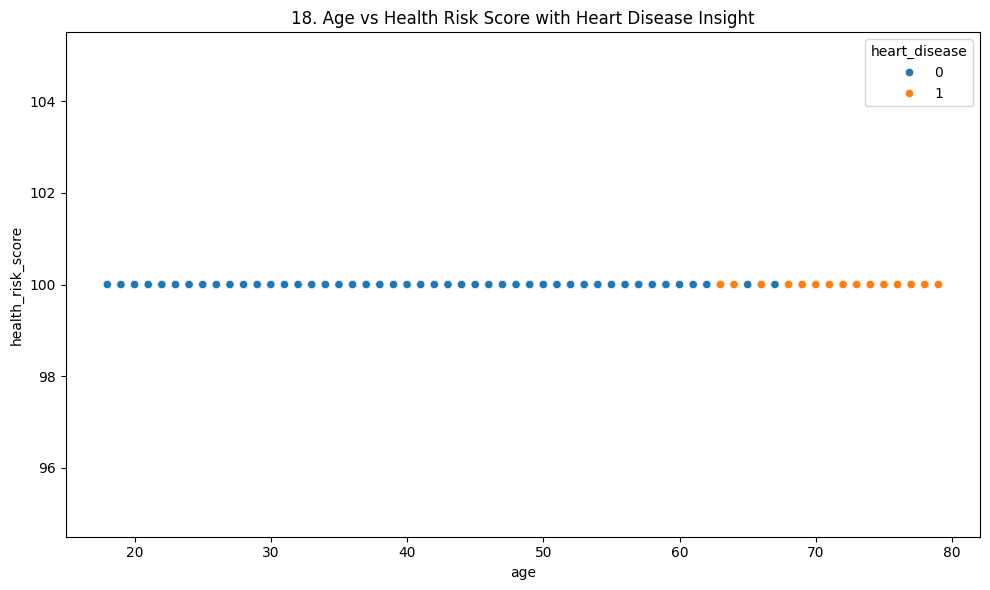

In [34]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='health_risk_score', hue='heart_disease', data= df)
plt.title(f'{plot_no}. Age vs Health Risk Score with Heart Disease Insight')
show_fig()
plot_no += 1



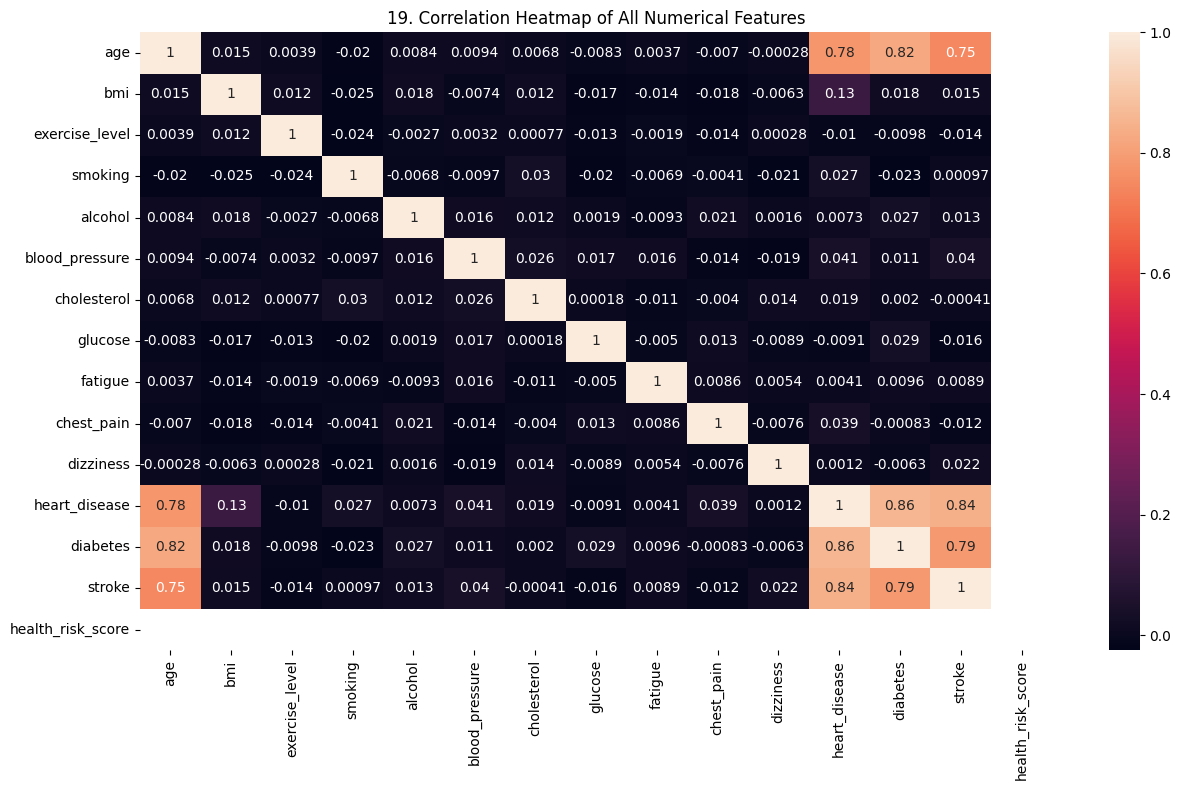

In [35]:
fig = plt.figure(figsize=(13, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of All Numerical Features')
show_fig()
plot_no += 1

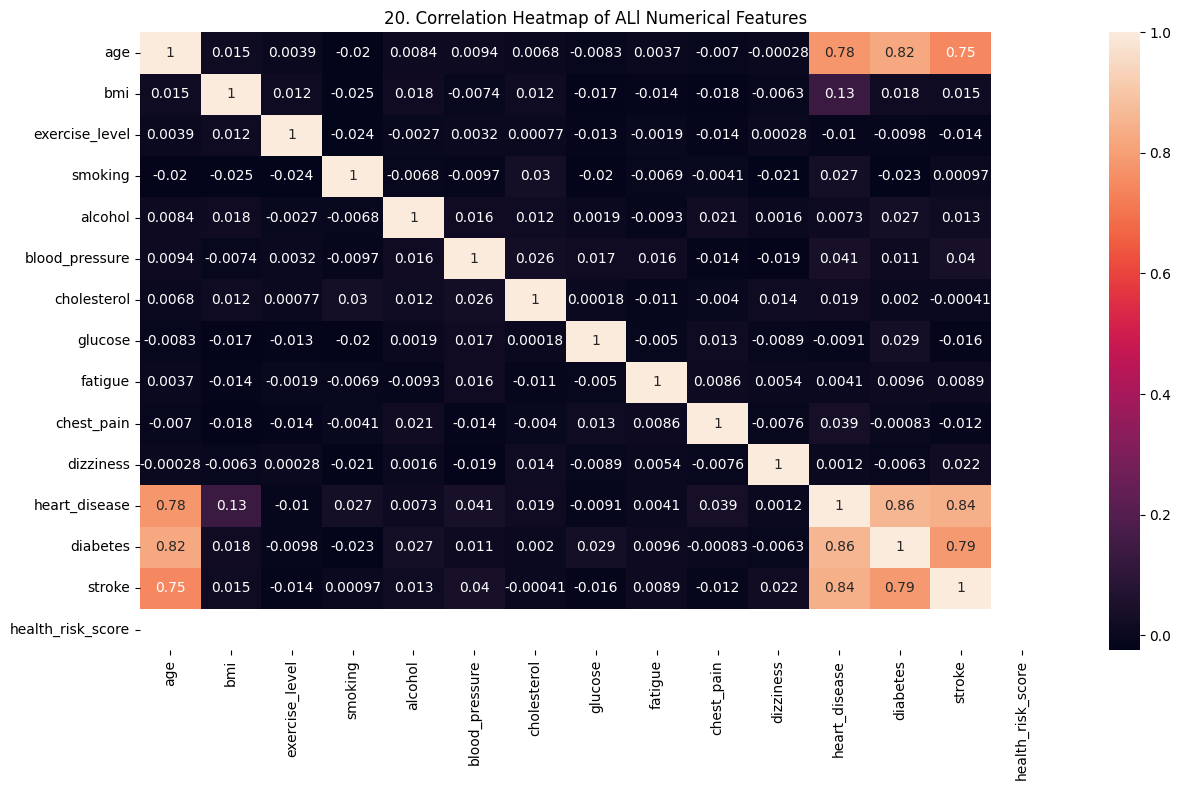

In [36]:
from numpy._core import numeric
fig = plt.figure(figsize = (13,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of ALl Numerical Features')
show_fig()
plot_no += 1


Model Training¶
convert categorical column to numeric¶


In [37]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [38]:
X = df.drop(columns = ['heart_disease','health_risk_score'])
y = df['heart_disease']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred = model.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.988


<Figure size 1000x600 with 0 Axes>

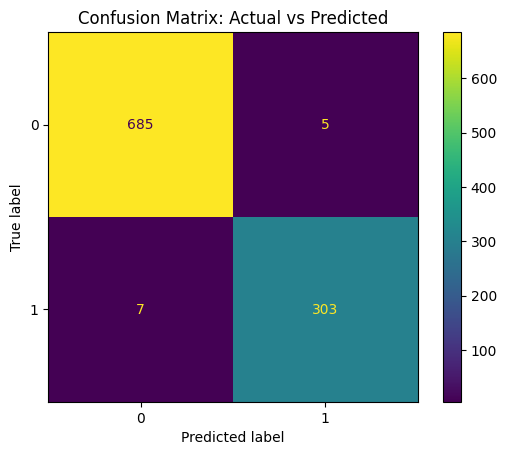

In [45]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()


<Figure size 1000x600 with 0 Axes>

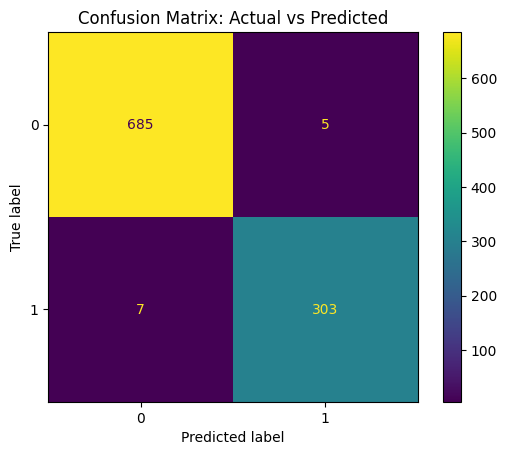

In [46]:
fig = plt.figure(figsize = (10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()

## Further Data Exploration for Business Insights

In [47]:
print(f'{plot_no}. Value counts for health_risk_score:\n{df["health_risk_score"].value_counts()}')
plot_no += 1

21. Value counts for health_risk_score:
health_risk_score
100.0    5000
Name: count, dtype: int64


The `health_risk_score` appears to be a constant value (100) for all entries. This means it doesn't provide any distinguishing information about individual health risks and therefore won't be useful for predicting `heart_disease` or any other health outcomes within this dataset. It was already dropped from the features (`X`) before model training, which was a good step.

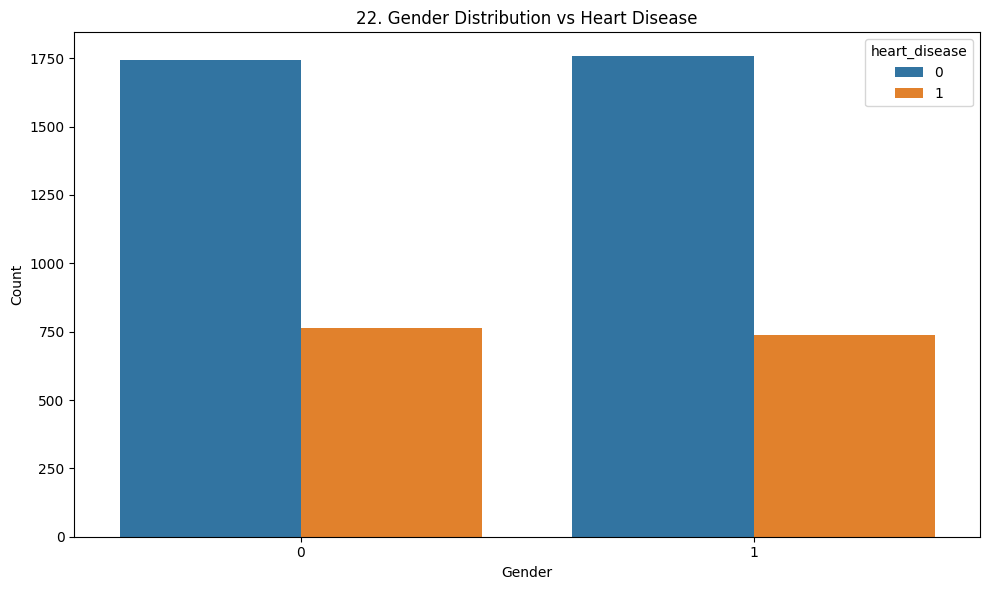

In [48]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', hue='heart_disease', data=df)
plt.title(f'{plot_no}. Gender Distribution vs Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Count')
show_fig()
plot_no += 1

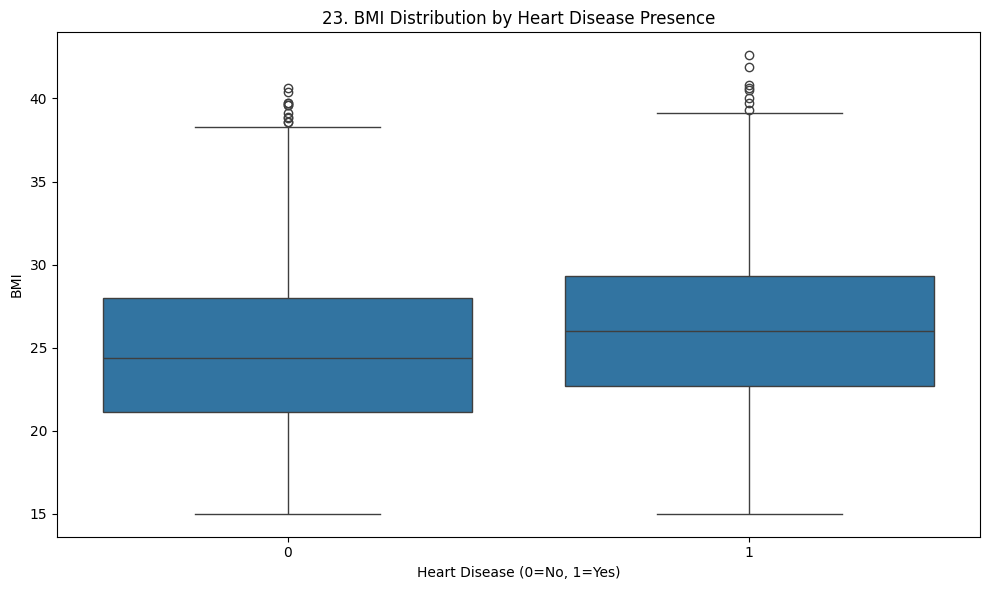

In [49]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='bmi', data=df)
plt.title(f'{plot_no}. BMI Distribution by Heart Disease Presence')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('BMI')
show_fig()
plot_no += 1

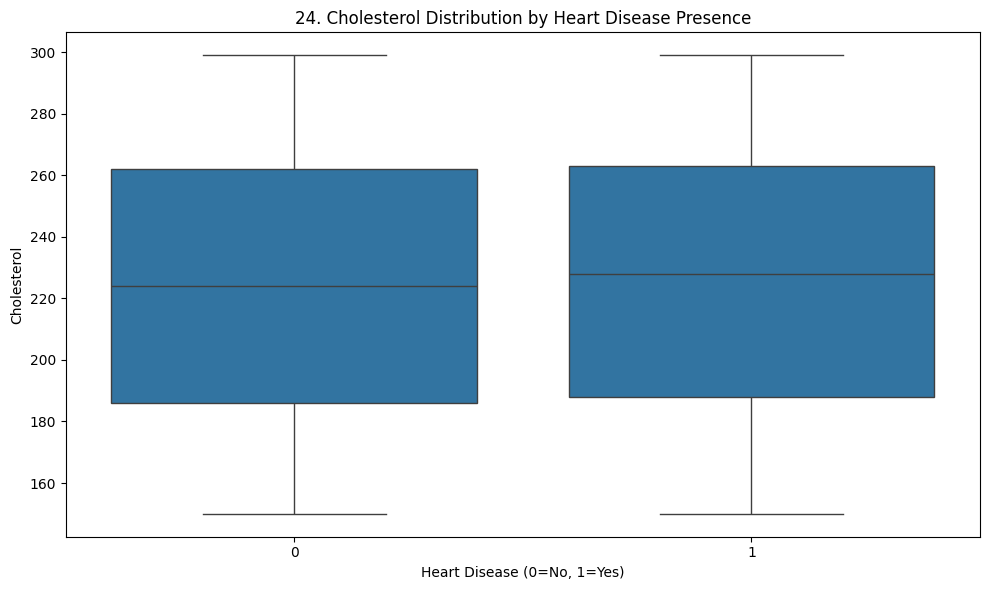

In [50]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.title(f'{plot_no}. Cholesterol Distribution by Heart Disease Presence')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Cholesterol')
show_fig()
plot_no += 1

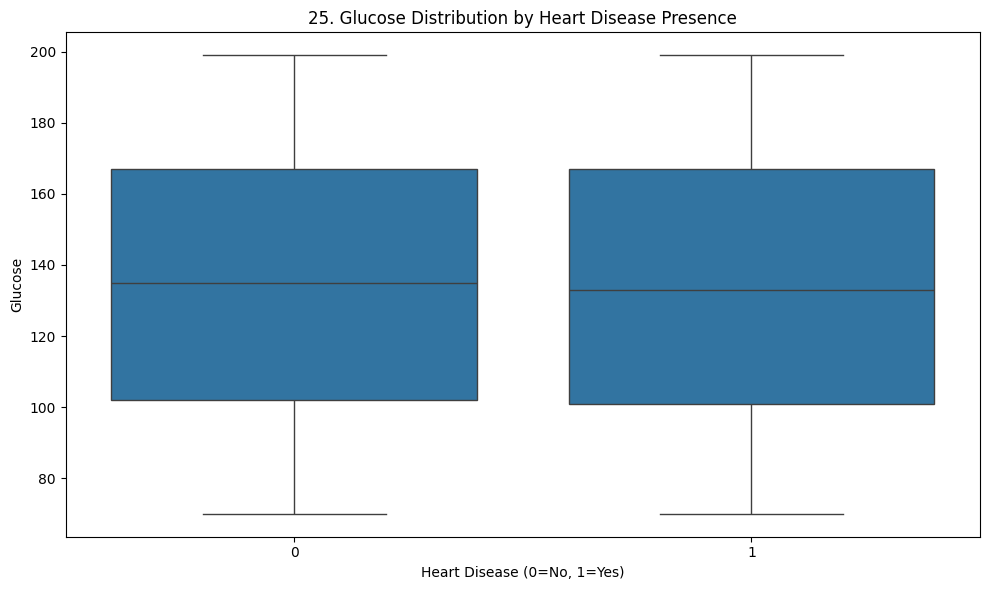

In [51]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='glucose', data=df)
plt.title(f'{plot_no}. Glucose Distribution by Heart Disease Presence')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Glucose')
show_fig()
plot_no += 1

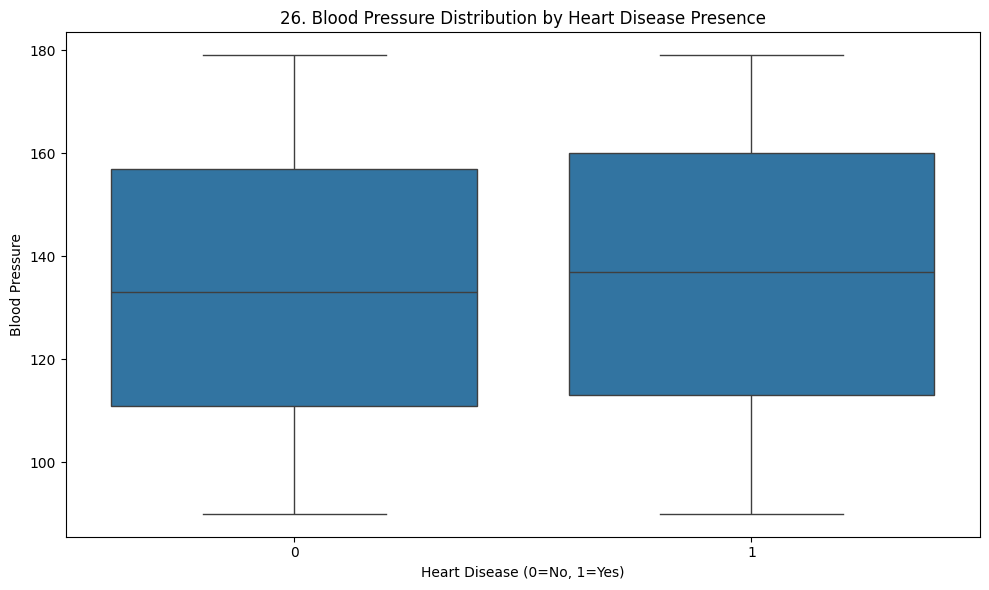

In [52]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='blood_pressure', data=df)
plt.title(f'{plot_no}. Blood Pressure Distribution by Heart Disease Presence')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Blood Pressure')
show_fig()
plot_no += 1

## Potential Business Recommendations

Based on the comprehensive exploratory data analysis and the logistic regression model, here are some potential business recommendations for a smart healthcare system:

1.  **Targeted Prevention Programs**:
    *   **Age-Based Screening**: The age distribution plot indicates that heart disease risk generally increases with age. Healthcare providers could implement more frequent screening and preventative interventions for individuals in older age groups.
    *   **Gender-Specific Interventions**: Further analysis on gender and heart disease (if significant differences were observed) could lead to tailored health campaigns. For instance, if one gender shows a higher propensity, resources can be allocated accordingly.

2.  **Lifestyle Modification Campaigns**:
    *   **Exercise Promotion**: The analysis showed a clear inverse relationship between exercise levels and heart disease. The healthcare system could launch initiatives to promote regular physical activity, possibly through partnerships with gyms, community centers, or offering digital fitness programs.
    *   **Smoking Cessation and Alcohol Moderation**: Both smoking and alcohol consumption showed an impact on heart disease. Campaigns focused on smoking cessation and responsible alcohol consumption can significantly reduce risk factors.

3.  **Early Detection and Management of Risk Factors**:
    *   **BMI Management**: Higher BMI tends to be associated with heart disease. Programs focusing on weight management, nutrition counseling, and healthy eating habits can be beneficial.
    *   **Cholesterol, Glucose, and Blood Pressure Monitoring**: Since these metrics are strong indicators of heart disease, a smart healthcare system can implement proactive monitoring programs, especially for individuals showing borderline or high values. This could involve regular automated reminders for check-ups or personalized dietary advice.
    *   **Fatigue, Chest Pain, and Dizziness Awareness**: These symptoms are often linked to heart disease. Educational campaigns can raise awareness about these symptoms, encouraging timely medical consultation, and potentially integrating symptom checkers into the healthcare platform.

4.  **Integrated Care Pathways**:
    *   **Diabetes and Heart Disease**: Given the significant overlap between diabetes and heart disease, an integrated care pathway that manages both conditions simultaneously can improve patient outcomes. This includes coordinated appointments, shared medical records, and multidisciplinary care teams.

5.  **Data-Driven Patient Engagement**:
    *   Leverage the predictive model to identify individuals at high risk for heart disease, even if they don't yet show severe symptoms. These individuals can then be prioritized for early interventions, personalized health coaching, and regular follow-ups. This proactive approach can lead to better patient outcomes and potentially reduce long-term healthcare costs.